In [31]:
from utils.data_utils import MnistDataHelper
from os.path import join

import numpy as np
import matplotlib.pyplot as plt

## Loading the Data

In [32]:
input_path = './input'
training_images_filepath = join(input_path, 'train-images-idx3-ubyte/train-images.idx3-ubyte')
training_labels_filepath = join(input_path, 'train-labels-idx1-ubyte/train-labels.idx1-ubyte')
test_images_filepath = join(input_path, 't10k-images-idx3-ubyte/t10k-images.idx3-ubyte')
test_labels_filepath = join(input_path, 't10k-labels-idx1-ubyte/t10k-labels.idx1-ubyte')

mnist_dataloader = MnistDataHelper(training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath)
(x_train, y_train), (x_test, y_test) = mnist_dataloader.load_data()

x_train = np.array(x_train) 
x_test = np.array(x_test)

x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)

x_train = x_train / x_train.max()
x_test = x_test / x_test.max()

x_train.shape, x_test.shape

((60000, 784), (10000, 784))

## Building the Networks

In [33]:
class Layer:
    def __init__(self, weights, biases):
        self.weights = weights
        self.biases = biases
    
    def forward(self, input):
        dot_product = np.dot(input, self.weights)
        return dot_product + self.biases

class ReluLayer(Layer):
    def __init__(self, weights, biases):
        super().__init__(weights, biases)
        
    def relu(self, input):
        return np.maximum(0, input)
    
    def forward(self, input):
        result = super().forward(input)
        return self.relu(result)

class SigmoidLayer(Layer):
    def __init__(self, weights, biases):
        super().__init__(weights, biases)
    
    def sigmoid(self, input):
        return 1 / (1 + np.exp(-input))
    
    def forward(self, input):
        result = super().forward(input)
        return self.sigmoid(result)

In [34]:
def initialize_layers(input_size, hidden1_size, hidden2_size, latent_size, hidden3_size, hidden4_size, output_size):
    hidden1_weights = np.random.normal(0, np.sqrt(2.0 / input_size), size=(input_size, hidden1_size))
    hidden1_biases = np.zeros(shape=(hidden1_size,))
    hidden1_layer = ReluLayer(hidden1_weights, hidden1_biases)

    hidden2_weights = np.random.normal(0, np.sqrt(2.0 / hidden1_size), size=(hidden1_size, hidden2_size))
    hidden2_biases = np.zeros(shape=(hidden2_size,))
    hidden2_layer = ReluLayer(hidden2_weights, hidden2_biases)

    latent_weights = np.random.normal(0, np.sqrt(2.0 / hidden2_size), size=(hidden2_size, latent_size))
    latent_biases = np.zeros(shape=(latent_size,))
    latent_layer = ReluLayer(latent_weights, latent_biases)
    
    hidden3_weights = np.random.normal(0, np.sqrt(2.0 / latent_size), size=(latent_size, hidden3_size))
    hidden3_biases = np.zeros(shape=(hidden3_size,))
    hidden3_layer = ReluLayer(hidden3_weights, hidden3_biases)
    
    hidden4_weights = np.random.normal(0, np.sqrt(2.0 / hidden3_size), size=(hidden3_size, hidden4_size))
    hidden4_biases = np.zeros(shape=(hidden4_size,))
    hidden4_layer = ReluLayer(hidden4_weights, hidden4_biases)
    
    output_weights = np.random.normal(0, np.sqrt(2.0 / hidden4_size), size=(hidden4_size, output_size))
    output_biases = np.zeros(shape=(output_size,))
    output_layer = SigmoidLayer(output_weights, output_biases)

    return [hidden1_layer, hidden2_layer, latent_layer, hidden3_layer, hidden4_layer, output_layer]

In [35]:
class Network:
    def __init__(self, layers):
        self.layers = layers
    
    def forward(self, input):
        outputs = []
        
        for layer in self.layers:
            output = layer.forward(input)
            outputs.append(output)
            input = output
            
        return outputs

    def clip_grad(self, grad, clip_value=5.0):
        norm = np.linalg.norm(grad)
        if norm > clip_value:
            grad = grad * (clip_value / norm)
            
        return grad

    def backward(self, input, outputs, batch_size, target):
        output_error = outputs[-1] - target
        output_w_grad = outputs[-2].T @ output_error / batch_size
        output_b_grad = np.mean(output_error, axis=0)

        hidden4_error = np.dot(output_error, self.layers[-1].weights.T) * (outputs[-2] > 0)
        hidden4_w_grad = outputs[-3].T @ hidden4_error / batch_size
        hidden4_b_grad = np.mean(hidden4_error, axis=0)
        
        hidden3_error = np.dot(hidden4_error, self.layers[-2].weights.T) * (outputs[-3] > 0)
        hidden3_w_grad = outputs[-4].T @ hidden3_error / batch_size
        hidden3_b_grad = np.mean(hidden3_error, axis=0)

        latent_error = np.dot(hidden3_error, self.layers[-3].weights.T) * (outputs[-4] > 0)    
        latent_w_grad = outputs[-5].T @ latent_error / batch_size
        latent_b_grad = np.mean(latent_error, axis=0)
        
        hidden2_error = np.dot(latent_error, self.layers[-4].weights.T) * (outputs[-5] > 0)
        hidden2_w_grad = outputs[-6].T @ hidden2_error / batch_size
        hidden2_b_grad = np.mean(hidden2_error, axis=0)
        
        hidden1_error = np.dot(hidden2_error, self.layers[-5].weights.T) * (outputs[-6] > 0)
        hidden1_w_grad = input.T @ hidden1_error / batch_size
        hidden1_b_grad = np.mean(hidden1_error, axis=0)
        
        w_grads = [
            self.clip_grad(output_w_grad),
            self.clip_grad(hidden4_w_grad),
            self.clip_grad(hidden3_w_grad),
            self.clip_grad(latent_w_grad),
            self.clip_grad(hidden2_w_grad),
            self.clip_grad(hidden1_w_grad)
        ]

        b_grads = [
            self.clip_grad(output_b_grad),
            self.clip_grad(hidden4_b_grad),
            self.clip_grad(hidden3_b_grad),
            self.clip_grad(latent_b_grad),
            self.clip_grad(hidden2_b_grad),
            self.clip_grad(hidden1_b_grad)
        ]
        
        return w_grads, b_grads

    def update_parameters(self, learning_rate, w_grads, b_grads):
        self.layers[-1].weights -= w_grads[0] * learning_rate
        self.layers[-1].biases -= b_grads[0] * learning_rate

        self.layers[-2].weights -= w_grads[1] * learning_rate
        self.layers[-2].biases -= b_grads[1] * learning_rate

        self.layers[-3].weights -= w_grads[2] * learning_rate
        self.layers[-3].biases -= b_grads[2] * learning_rate

        self.layers[-4].weights -= w_grads[3] * learning_rate
        self.layers[-4].biases -= b_grads[3] * learning_rate

        self.layers[-5].weights -= w_grads[4] * learning_rate
        self.layers[-5].biases -= b_grads[4] * learning_rate

        self.layers[-6].weights -= w_grads[5] * learning_rate
        self.layers[-6].biases -= b_grads[5] * learning_rate

In [ ]:
network1 = Network(initialize_layers(784, 256, 64, 36, 64, 256, 784))
network2 = Network(initialize_layers(784, 256, 64, 16, 64, 256, 784))
network3 = Network(initialize_layers(784, 256, 64, 9, 64, 256, 784))
network4 = Network(initialize_layers(784, 256, 64, 4, 64, 256, 784))

In [37]:
def compute_loss(output, target):
    return np.mean((output - target) ** 2)

## Training the Networks

In [ ]:
def train(x_train, network, learning_rate, epochs, batch_size, adaptive_learning=True):
    num_samples = x_train.shape[0]
    epoch_losses = []
    epochs_since_update = 0
    
    for epoch in range(epochs):
        total_loss = 0
        
        for i in range(0, num_samples, batch_size):
            batch_inputs = x_train[i:i+batch_size]
            batch_targets = batch_inputs
            
            outputs = network.forward(batch_inputs)
            
            loss = compute_loss(outputs[-1], batch_targets)
            total_loss += loss
            
            w_grads, b_grads = network.backward(batch_inputs, outputs, batch_size, batch_targets)
            network.update_parameters(learning_rate, w_grads, b_grads)
            
        avg_loss = total_loss / num_samples
        
        if adaptive_learning and epochs_since_update > 5:
            loss_percentage = avg_loss / epoch_losses[-1]
            
            if loss_percentage >= 0.8:
                learning_rate *= 0.8
                epochs_since_update = 0
                    
        epoch_losses.append(avg_loss)
        epochs_since_update += 1
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch + 1}/{epochs} completed | Avg. Loss: {avg_loss:.10f} | Learning Rate: {learning_rate:.8f}')

In [39]:
hyperparameters = {
    "learning_rate": 0.01,
    "epochs": 100,
    "batch_size": 32
}

In [40]:
train(x_train, network1, hyperparameters["learning_rate"], hyperparameters["epochs"], hyperparameters["batch_size"])

Epoch 10/100 completed | Avg. Loss: 0.0004868632 | Learning Rate: 0.00800000
Epoch 20/100 completed | Avg. Loss: 0.0003815228 | Learning Rate: 0.00512000
Epoch 30/100 completed | Avg. Loss: 0.0003495130 | Learning Rate: 0.00409600
Epoch 40/100 completed | Avg. Loss: 0.0003252374 | Learning Rate: 0.00262144
Epoch 50/100 completed | Avg. Loss: 0.0003118416 | Learning Rate: 0.00167772
Epoch 60/100 completed | Avg. Loss: 0.0003052573 | Learning Rate: 0.00134218
Epoch 70/100 completed | Avg. Loss: 0.0003000526 | Learning Rate: 0.00085899
Epoch 80/100 completed | Avg. Loss: 0.0002968635 | Learning Rate: 0.00054976
Epoch 90/100 completed | Avg. Loss: 0.0002951128 | Learning Rate: 0.00043980
Epoch 100/100 completed | Avg. Loss: 0.0002936948 | Learning Rate: 0.00028147


In [44]:
train(x_train, network2, hyperparameters["learning_rate"], hyperparameters["epochs"], hyperparameters["batch_size"])

Epoch 10/100 completed | Avg. Loss: 0.0005083976 | Learning Rate: 0.00800000
Epoch 20/100 completed | Avg. Loss: 0.0004542708 | Learning Rate: 0.00512000
Epoch 30/100 completed | Avg. Loss: 0.0004315757 | Learning Rate: 0.00409600
Epoch 40/100 completed | Avg. Loss: 0.0004159538 | Learning Rate: 0.00262144
Epoch 50/100 completed | Avg. Loss: 0.0004067988 | Learning Rate: 0.00167772
Epoch 60/100 completed | Avg. Loss: 0.0004016946 | Learning Rate: 0.00134218
Epoch 70/100 completed | Avg. Loss: 0.0003977858 | Learning Rate: 0.00085899
Epoch 80/100 completed | Avg. Loss: 0.0003952271 | Learning Rate: 0.00054976
Epoch 90/100 completed | Avg. Loss: 0.0003937005 | Learning Rate: 0.00043980
Epoch 100/100 completed | Avg. Loss: 0.0003925045 | Learning Rate: 0.00028147


In [45]:
train(x_train, network3, hyperparameters["learning_rate"], hyperparameters["epochs"], hyperparameters["batch_size"])

Epoch 10/100 completed | Avg. Loss: 0.0007336560 | Learning Rate: 0.00800000
Epoch 20/100 completed | Avg. Loss: 0.0006339123 | Learning Rate: 0.00512000
Epoch 30/100 completed | Avg. Loss: 0.0005936566 | Learning Rate: 0.00409600
Epoch 40/100 completed | Avg. Loss: 0.0005695807 | Learning Rate: 0.00262144
Epoch 50/100 completed | Avg. Loss: 0.0005557274 | Learning Rate: 0.00167772
Epoch 60/100 completed | Avg. Loss: 0.0005477976 | Learning Rate: 0.00134218
Epoch 70/100 completed | Avg. Loss: 0.0005421374 | Learning Rate: 0.00085899
Epoch 80/100 completed | Avg. Loss: 0.0005384570 | Learning Rate: 0.00054976
Epoch 90/100 completed | Avg. Loss: 0.0005361920 | Learning Rate: 0.00043980
Epoch 100/100 completed | Avg. Loss: 0.0005345064 | Learning Rate: 0.00028147


In [46]:
train(x_train, network4, hyperparameters["learning_rate"], hyperparameters["epochs"], hyperparameters["batch_size"])

Epoch 10/100 completed | Avg. Loss: 0.0009943631 | Learning Rate: 0.00800000
Epoch 20/100 completed | Avg. Loss: 0.0009219788 | Learning Rate: 0.00512000
Epoch 30/100 completed | Avg. Loss: 0.0008951233 | Learning Rate: 0.00409600
Epoch 40/100 completed | Avg. Loss: 0.0008793082 | Learning Rate: 0.00262144
Epoch 50/100 completed | Avg. Loss: 0.0008701670 | Learning Rate: 0.00167772
Epoch 60/100 completed | Avg. Loss: 0.0008648127 | Learning Rate: 0.00134218
Epoch 70/100 completed | Avg. Loss: 0.0008612139 | Learning Rate: 0.00085899
Epoch 80/100 completed | Avg. Loss: 0.0008589134 | Learning Rate: 0.00054976
Epoch 90/100 completed | Avg. Loss: 0.0008573397 | Learning Rate: 0.00043980
Epoch 100/100 completed | Avg. Loss: 0.0008563048 | Learning Rate: 0.00028147


## Visualizing Results

In [65]:
def plot_outputs(x_test, n_samples, networks):
    batch_inputs = x_test[np.random.randint(0, x_test.shape[0], size=n_samples)]
    
    for network in networks:
        outputs = network.forward(batch_inputs)

        stages = [
            ("Input", batch_inputs),
            ("Hidden1", outputs[-6]),
            ("Hidden2", outputs[-5]),
            ("Latent", outputs[-4]),
            ("Hidden3", outputs[-3]),
            ("Hidden4", outputs[-2]),
            ("Output", outputs[-1]),
        ]

        n_stages = len(stages)

        fig, axes = plt.subplots(n_samples, n_stages, figsize=(n_stages*2, n_samples*2), squeeze=False)

        for row in range(n_samples):
            for col, (name, data) in enumerate(stages):
                ax = axes[row, col] 

                img = data[row] 

                if img.size == 784:
                    img = img.reshape(28, 28)
                else:
                    side = int(np.sqrt(img.size))
                    if side * side == img.size:
                        img = img.reshape(side, side)
                    else:
                        img = img.reshape(1, -1)

                ax.imshow(img, cmap="gray")
                ax.axis("off")
                ax.set_xlabel(name)

        plt.tight_layout()
        plt.show()

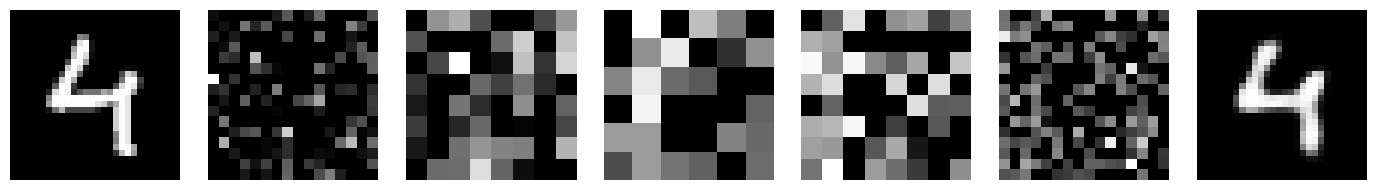

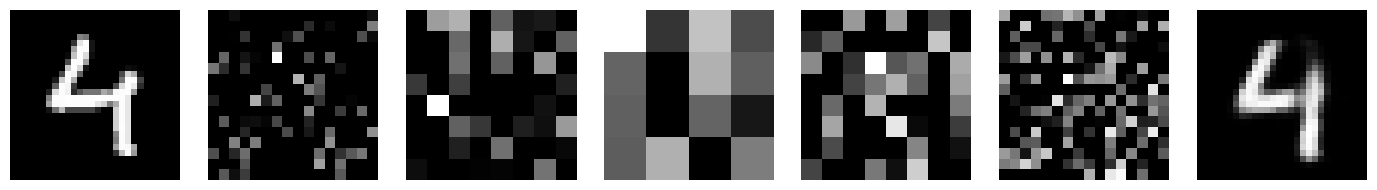

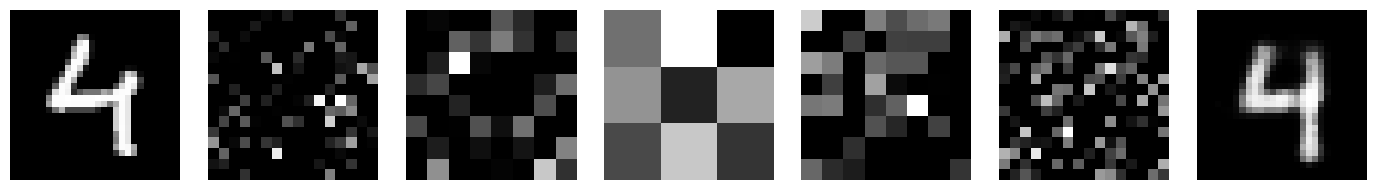

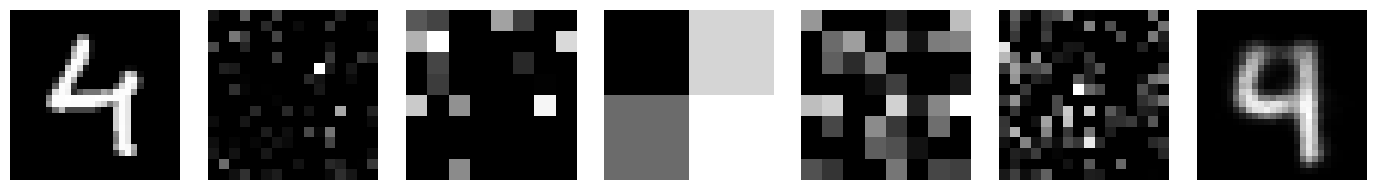

In [85]:
plot_outputs(x_test, 1, [network1, network2, network3, network4])

In [86]:
def test(x_test, network):
    _, _, _, _, _, output = network.forward(x_test)
    
    loss = compute_loss(output, x_test)
    return loss.mean()


print(f"Network 1 | Mean total loss: {test(x_test, network1):.6f}")
print(f"Network 2 | Mean total loss: {test(x_test, network2):.6f}")
print(f"Network 3 | Mean total loss: {test(x_test, network3):.6f}")
print(f"Network 4 | Mean total loss: {test(x_test, network4):.6f}")

Network 1 | Mean total loss: 0.009229
Network 2 | Mean total loss: 0.012692
Network 3 | Mean total loss: 0.017244
Network 4 | Mean total loss: 0.028319
